## Set Up

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.api import OLS, add_constant

In [7]:
# Load CSV
df = pd.read_csv("/content/515.csv", parse_dates=["Date"], index_col="Date")

# Drop rows with missing values (from returns and diffs)
df = df.dropna()
df.head()

,NVDA_Close,QQQ_Close,AI_Trend,ChatGPT_Trend,DeepSeek_Trend,nvda_return,qqq_return,ai_diff,chatgpt_diff,deepseek_diff,chatgpt_shock,deepseek_shock
Date,,,,,,,,,,,,
2020-03-29,6.32,185.30,5,0.0,0.0,-0.035430,-0.010470,0,0.0,0.0,0,0
2020-04-05,6.10,183.37,5,0.0,0.0,0.074225,0.091102,0,0.0,0.0,0,0
2020-04-12,6.57,200.86,4,0.0,0.0,0.106729,0.069378,-1,0.0,0.0,0,0
2020-04-19,7.31,215.29,4,0.0,0.0,-0.009622,-0.006758,0,0.0,0.0,0,0
2020-04-26,7.24,213.84,5,0.0,0.0,-0.023761,-0.005157,1,0.0,0.0,0,0


from matplotlib import pyplot as plt
_df_0['NVDA_Close'].plot(kind='hist', bins=20, title='NVDA_Close')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['QQQ_Close'].plot(kind='hist', bins=20, title='QQQ_Close')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['AI_Trend'].plot(kind='hist', bins=20, title='AI_Trend')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['nvda_return'].plot(kind='hist', bins=20, title='nvda_return')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Date']
  ys = series['nvda_return']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_11.sort_values('Date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Date')
_ = plt.ylabel('nvda_return')

from matplotlib import pyplot as plt
_df_12['NVDA_Close'].plot(kind='line', figsize=(8, 4), title='NVDA_Close')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_13['QQQ_Close'].plot(kind='line', figsize=(8, 4), title='QQQ_Close')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_14['AI_Trend'].plot(kind='line', figsize=(8, 4), title='AI_Trend')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_15['nvda_return'].plot(kind='line', figsize=(8, 4), title='nvda_return')
plt.gca().spines[['top', 'right']].set_visible(False)

# Stationary Test

In [ ]:
result = adfuller(df['NVDA_Close'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])


ADF Statistic: 0.3560938320107905
p-value: 0.9797766369502686


In [50]:
result = adfuller(df['nvda_return'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -14.942683672644444
p-value: 1.3154383340387604e-27


In [40]:
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")  # cleaner output

# We'll fix d=1 (from ADF test)
best_aic = np.inf
best_order = None
aic_table = []

# Search over a range of p and q
for p in range(0, 4):
    for q in range(0, 4):
        try:
            model = SARIMAX(df_clean['NVDA_Close'],
                            exog=df_clean[['QQQ_Close', 'AI_Trend', 'ChatGPT_Trend', 'DeepSeek_Trend', 'chatgpt_shock', 'deepseek_shock']],
                            order=(p, 1, q))
            result = model.fit(disp=False)
            aic = result.aic
            aic_table.append((p, q, aic))
            if aic < best_aic:
                best_aic = aic
                best_order = (p, 1, q)
        except:
            continue

print("Best ARIMA order:", best_order)
print("Best AIC:", best_aic)




Best ARIMA order: (2, 1, 3)
Best AIC: 1341.098620751972


# ACF

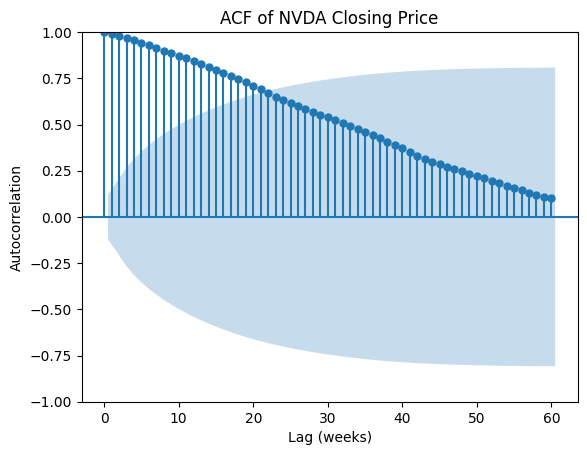

In [39]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# If you're testing raw NVDA prices (not recommended for seasonality):
plot_acf(df['NVDA_Close'].dropna(), lags=60)
plt.title('ACF of NVDA Closing Price')
plt.xlabel('Lag (weeks)')
plt.ylabel('Autocorrelation')
plt.show()


<Figure size 1000x400 with 0 Axes>

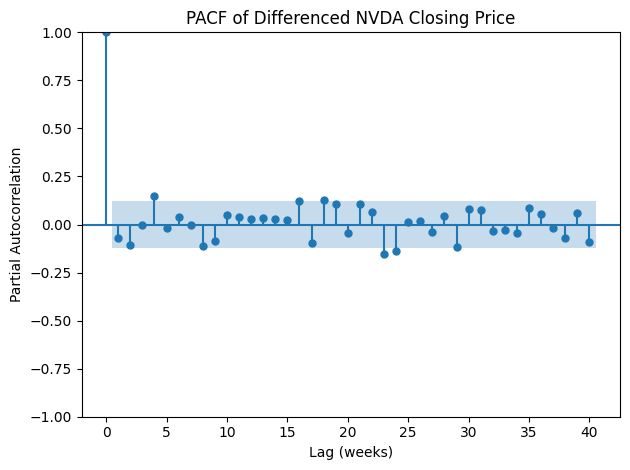

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf

# Load and prepare your data
df = pd.read_csv('/content/515.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Difference NVDA_Close to make it stationary
df['nvda_diff'] = df['NVDA_Close'].diff()
diff_series = df['nvda_diff'].dropna()

# Plot PACF
plt.figure(figsize=(10, 4))
plot_pacf(diff_series, lags=40, alpha=0.05, method='ywm')
plt.title("PACF of Differenced NVDA Closing Price")
plt.xlabel("Lag (weeks)")
plt.ylabel("Partial Autocorrelation")
plt.tight_layout()
plt.show()


# SARIMAX



In [42]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX

# STEP 1: Sort index and prepare data
df = df.sort_index()

# STEP 2: Clean up and check for NaNs/infs
cols = ['NVDA_Close', 'QQQ_Close', 'AI_Trend', 'ChatGPT_Trend', 'DeepSeek_Trend', 'chatgpt_shock', 'deepseek_shock']
df[cols] = df[cols].replace([np.inf, -np.inf], np.nan)
df_clean = df.dropna(subset=cols)

# STEP 3: Define target and exogenous variables
y = df_clean['NVDA_Close']
exog = df_clean[['QQQ_Close', 'AI_Trend', 'ChatGPT_Trend', 'DeepSeek_Trend', 'chatgpt_shock', 'deepseek_shock']]

# STEP 4: Fit ARIMAX model (ARIMA(1,1,1) with exogenous vars)
model = SARIMAX(y, order=(2, 1, 3), exog=exog)
result = model.fit()

# STEP 5: Show model summary
print(result.summary())


                               SARIMAX Results                                
Dep. Variable:             NVDA_Close   No. Observations:                  262
Model:               SARIMAX(2, 1, 3)   Log Likelihood                -658.549
Date:                Thu, 17 Apr 2025   AIC                           1341.099
Time:                        00:08:21   BIC                           1383.873
Sample:                    03-29-2020   HQIC                          1358.292
                         - 03-30-2025                                         
Covariance Type:                  opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
QQQ_Close          0.2076      0.016     12.706      0.000       0.176       0.240
AI_Trend          -0.0417      0.052     -0.799      0.424      -0.144       0.061
ChatGPT_Trend      0.0853      0.036





# GARCH

In [53]:
pip install arch



SyntaxError: invalid syntax (<ipython-input-53-78d9c43f806e>, line 1)

In [52]:
from arch import arch_model

# Fit GARCH(1,1) with exogenous variables in the mean equation
model = arch_model(y, vol='GARCH', p=1, q=1, mean='ARX', lags=1, x=X)
result = model.fit(disp='off')

# Print summary
print(result.summary())



                          AR-X - GARCH Model Results                          
Dep. Variable:            nvda_return   R-squared:                       0.029
Mean Model:                      AR-X   Adj. R-squared:                  0.002
Vol Model:                      GARCH   Log-Likelihood:               -852.700
Distribution:                  Normal   AIC:                           1727.40
Method:            Maximum Likelihood   BIC:                           1766.52
                                        No. Observations:                  259
Date:                Thu, Apr 17 2025   Df Residuals:                      251
Time:                        00:20:48   Df Model:                            8
                                    Mean Model                                   
                     coef    std err          t      P>|t|       95.0% Conf. Int.
---------------------------------------------------------------------------------
Const             -0.1868      2.990 -6.247